# RNN « à la vanille » — régression sur série temporelle



Dans ce notebook, vous allez implémenter et entraîner un **RNN simple** (tanh) avec PyTorch, puis analyser l’influence de certains choix (dimension cachée, fonction de coût, etc.).



**Objectifs pédagogiques**

- Mettre en forme des données temporelles pour un RNN (tenseurs 3D)

- Comprendre la différence entre *many-to-many* et *many-to-one*

- Entraîner un RNN PyTorch et interpréter la loss



**Conseil** : exécutez les cellules dans l’ordre. Lisez bien les questions en Markdown : certaines cellules sont volontairement incomplètes (à compléter).

## Notation (à garder en tête)



Dans la suite, on utilise la convention PyTorch (avec `batch_first=True`) :

- Entrée RNN : `(batch, seq_len, n_dim)`

- Sortie RNN : `(batch, seq_len, hid_dim)`

- État caché `h` : `(num_layers, batch, hid_dim)`



Dans ce TP, `n_dim=1` (une seule variable par pas de temps) et on cherche à **prédire le(s) point(s) suivant(s)** d’une série.

In [1]:
# But : introduction aux RNN sur une tâche de régression de série temporelle
# Étapes :
# 1) générer/visualiser une série (sinus)
# 2) construire les couples (X, Y) sous forme de séquences
# 3) entraîner un RNN PyTorch et visualiser la prédiction
# 4) comparer plusieurs configurations d'hyperparamètres


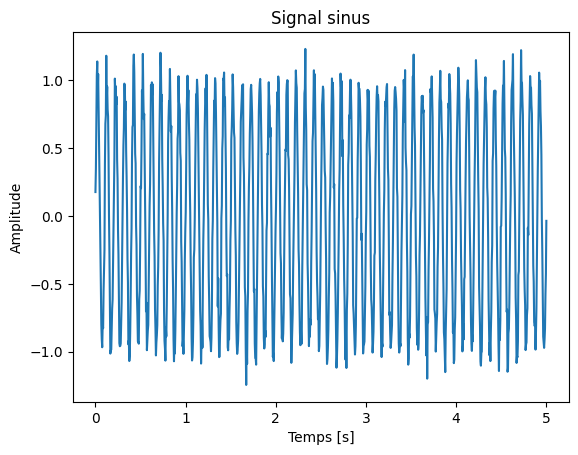

In [52]:
# Imports de base (calcul + affichage)
import numpy as np
import math
import matplotlib.pyplot as plt

# Série jouet : un sinus échantillonné
n_samp = 1000          # nombre d'échantillons
f = 10                 # fréquence (Hz)
tmin, tmax = 0, 5      # intervalle de temps (s)
noise_amp = 0.1       # amplitude du bruit (optionnel)

np.random.seed(0)  # pour la reproductibilité
t = np.linspace(tmin, tmax, n_samp)
x = np.sin(2 * math.pi * f * t) + noise_amp * np.random.randn(n_samp)

# Astuce : copie 1D pour les plots (optionnel)
xt = x.copy()

plt.plot(t, x)
plt.xlabel("Temps [s]")
plt.ylabel("Amplitude")
plt.title("Signal sinus")
plt.show()


In [53]:
# Mise en forme des données pour l'entrée du RNN
# Un RNN PyTorch (avec batch_first=True) attend : (batch, seq_len, n_dim)
# Ici, n_dim = 1 (un signal scalaire).

# Fenêtre temporelle de longueur len_seq.
# Tâche many-to-many : prédire la séquence décalée d'un pas.
#   X[t] = x[t : t+len_seq]
#   Y[t] = x[t+1 : t+len_seq+1]
many_to_many = True # si False, alors many to one
len_seq = 10

dataX, dataY = [], []
starts = range(0, len(x) - len_seq)

for i in starts:
    dataX.append([x[i : i + len_seq]])
    if many_to_many:
        # predire tout les points suivants (many-to-many)
        dataY.append([x[i + 1 : i + len_seq + 1]])
    else:
        # predire le prochain point (many-to-one)
        dataY.append([x[i + len_seq : i + len_seq + 1]])
dataX = np.array(dataX)
dataY = np.array(dataY)

# Remise en forme pour obtenir (nbatch, len_seq, 1)
dataX = np.reshape(dataX, (dataX.shape[0], dataX.shape[2], dataX.shape[1]))
dataY = np.reshape(dataY, (dataY.shape[0], dataY.shape[2], dataY.shape[1]))

print(f"Dimension des données en entrée  dataX : {dataX.shape}")
print(f"Dimension des données en sortie  dataY : {dataY.shape}")


Dimension des données en entrée  dataX : (990, 10, 1)
Dimension des données en sortie  dataY : (990, 10, 1)


In [4]:
# Hyperparamètres (valeurs initiales, à modifier pour l'exploration)
hid_dim = 2

# Dimensions déduites des données formatées
n_dim = dataX.shape[2] # == 1
len_seq = dataX.shape[1]

In [56]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# torchinfo est optionnel (uniquement pour afficher un résumé du modèle)
try:
    from torchinfo import summary as torchsumm
except Exception:
    torchsumm = None

torch.set_default_dtype(torch.float32)

# Choix du device : CUDA si disponible, sinon CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)

# Modèle RNN simple (tanh) + couche linéaire pour produire une sortie scalaire
class RNNModel(nn.Module):
    def __init__(self, hid_dim: int, n_dim: int ):
        super().__init__()
        self.hid_dim = hid_dim
        self.n_dim = n_dim
        self.rnn = nn.RNN(input_size=n_dim, hidden_size=hid_dim, batch_first=True, nonlinearity="tanh")
        self.fc = nn.Linear(hid_dim, 1)

    def forward(self, x, h0=None):
        # x: (batch, seq_len, n_dim)
        h0 = torch.zeros(1, x.size(0), self.hid_dim, device=x.device, dtype=x.dtype)
        assert x.shape[0] == h0.shape[1], (x.shape, h0.shape)
        out, h = self.rnn(x, h0)  # out: (batch, seq_len, hid_dim), h: (1, batch, hid_dim)
        out = self.fc(out)  # (batch, seq_len, 1)
        return out, h

# Instanciation du modèle
model = RNNModel(hid_dim, n_dim).to(device)

# Données (numpy -> torch). On les garde sur CPU dans le dataset puis on les envoie sur device batch par batch.
dataX_ = torch.tensor(dataX, dtype=torch.float32)
dataY_ = torch.tensor(dataY, dtype=torch.float32)
dataset = TensorDataset(dataX_, dataY_)


device = cuda


In [57]:
# Affichage du modèle (résumé optionnel si torchinfo est installé)
from IPython.display import display

display(model)
if torchsumm is not None:
    display(torchsumm(model, input_size=(1, len_seq, n_dim)))
else:
    print("(Info) `torchinfo` non installé : pas de résumé du modèle.")


RNNModel(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [1, 10, 1]                --
├─RNN: 1-1                               [1, 10, 16]               304
├─Linear: 1-2                            [1, 10, 1]                17
Total params: 321
Trainable params: 321
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [58]:
# Test rapide (sanity check) sur les dimensions
xtest = np.ones((4, len_seq, 1), dtype=np.float32)
htest = np.zeros((1, 4, model.hid_dim), dtype=np.float32)

xtest_ = torch.tensor(xtest).to(device)
htest_ = torch.tensor(htest).to(device)
print("x:", xtest_.shape, "h0:", htest_.shape)

out_rnn, h_rnn = model.rnn(xtest_, htest_)
print("rnn out:", out_rnn.shape, "h:", h_rnn.shape)

out, h = model(xtest_, htest_)
print("model out:", out.shape, "h:", h.shape)


x: torch.Size([4, 10, 1]) h0: torch.Size([1, 4, 16])
rnn out: torch.Size([4, 10, 16]) h: torch.Size([1, 4, 16])
model out: torch.Size([4, 10, 1]) h: torch.Size([1, 4, 16])


In [69]:
# Paramètres d'entraînement
batch_size = 8
n_epochs = 10

train_loader = DataLoader(dataset, shuffle=True, num_workers=1, batch_size=batch_size)

# Vérification des shapes (entrée/sortie)
A, B = next(iter(train_loader))
print("X batch:", A.shape, "Y batch:", B.shape)


X batch: torch.Size([8, 10, 1]) Y batch: torch.Size([8, 10, 1])


In [70]:
from collections import OrderedDict

# On construit un nom de fichier informatif pour sauvegarder le modèle
params = OrderedDict([
    ("hid_dim", hid_dim),
    ("len_seq", len_seq),
    ("batch_size", batch_size),
    ("n_epochs", n_epochs),
    ("many_to_many", many_to_many),
])

fname = "_".join([f"{key}={val}" for key, val in params.items()])
print(fname)


hid_dim=16_len_seq=10_batch_size=8_n_epochs=10_many_to_many=True


In [71]:
# Entraînement 
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ici on ne calcul que train loss, on fera proprement 
# avec de la validation dans la deuxieme partie
loss_history = [] 
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        y_hat, _ = model(xb)
        loss = criterion(y_hat, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)

    mse = running_loss / max(n_seen, 1)
    loss_history.append(mse)
    print(f"Epoch {epoch:03d} | MSE={mse:.6f}")


Epoch 001 | MSE=0.031525
Epoch 002 | MSE=0.031260
Epoch 003 | MSE=0.030987
Epoch 004 | MSE=0.030689
Epoch 005 | MSE=0.030418
Epoch 006 | MSE=0.030364
Epoch 007 | MSE=0.029992
Epoch 008 | MSE=0.029919
Epoch 009 | MSE=0.029698
Epoch 010 | MSE=0.029449


In [72]:
# Sauvegarde du modèle entraîné
torch.save(model.state_dict(), f"{fname}.pth")
print("Saved:", f"{fname}.pth")


Saved: hid_dim=16_len_seq=10_batch_size=8_n_epochs=10_many_to_many=True.pth


In [73]:
# Chargement du modèle pour la prédiction (mêmes hyperparamètres)
model2 = RNNModel(hid_dim, n_dim).to(device)
model2.load_state_dict(torch.load(f"{fname}.pth", map_location=device))
model2.eval()


RNNModel(
  (rnn): RNN(1, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)

MSE on whole sequence: 0.101640


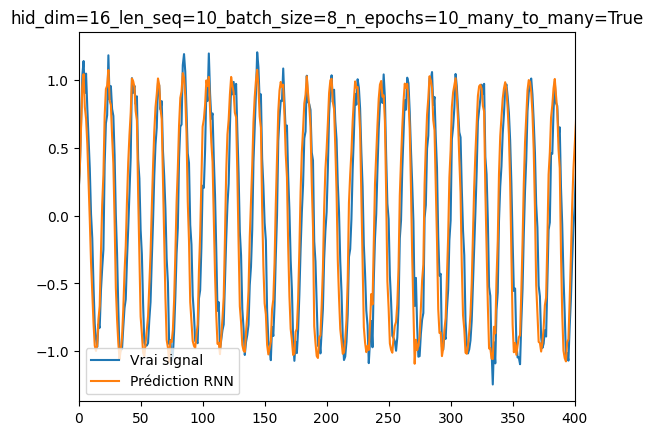

In [74]:
# Prédiction sur toute la séquence (pour visualiser)
# x est de shape (1, n_samp, 1)

x_reshaped = np.reshape(x, (1, n_samp, 1))
with torch.no_grad():
    yt, _ = model2(
        torch.tensor(x_reshaped, dtype=torch.float32).to(device),
        torch.zeros((1, 1, hid_dim), dtype=torch.float32).to(device),
    )

yt = yt.detach().cpu().numpy()
MSE = np.mean((yt.flatten() - x.flatten())**2)
print(f'MSE on whole sequence: {MSE:.6f}')

plt.plot(x.flatten(), label="Vrai signal")
plt.plot(yt[0, :, 0], label="Prédiction RNN")
plt.legend()
plt.xlim(0, 400)
plt.title(fname)
plt.show()


### Experiences à faire: recalculez le modele plusieurs fois et observez la stabilité des resultats. 

#### On remarque qu'en ne changeant aucun paramètres mais en releçant le code, le résultat obtenu de la prédiction est différent ainsi les résultats ne sont pas stables sur la répétabilité.

## Question: comment faire la meme chose avec LSTM?

In [75]:
# Modèle LSTM + couche linéaire pour produire une sortie scalaire
class LSTMModel(nn.Module):
    def __init__(self, hid_dim: int, n_dim: int):
        super().__init__()
        self.hid_dim = hid_dim
        self.n_dim = n_dim
        
        # Remplacement ici : on utilise nn.LSTM et on retire "nonlinearity"
        self.lstm = nn.LSTM(input_size=n_dim, hidden_size=hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, 1)

    def forward(self, x, hidden=None):
        # x: (batch, seq_len, n_dim)
        
        # Si aucun état initial n'est fourni, on initialise h0 ET c0 à zéro
        if hidden is None:
            h0 = torch.zeros(1, x.size(0), self.hid_dim, device=x.device, dtype=x.dtype)
            c0 = torch.zeros(1, x.size(0), self.hid_dim, device=x.device, dtype=x.dtype)
            hidden = (h0, c0)
            
        # Le LSTM prend en entrée (x, (h0, c0)) et renvoie (out, (h, c))
        out, (h, c) = self.lstm(x, hidden)  # out: (batch, seq_len, hid_dim)
        out = self.fc(out)  # (batch, seq_len, 1)
        
        return out, (h, c)

# Instanciation du nouveau modèle
model_lstm = LSTMModel(hid_dim, n_dim).to(device)

In [76]:
# Entraînement du LSTM
criterion = nn.MSELoss()
# On n'oublie pas de passer les paramètres du NOUVEAU modèle à l'optimiseur
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

loss_history_lstm = [] 
for epoch in range(1, n_epochs + 1):
    model_lstm.train()
    running_loss = 0.0
    n_seen = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer_lstm.zero_grad()
        
        # model_lstm renvoie out et le tuple (h, c). On ignore l'état avec "_"
        y_hat, _ = model_lstm(xb)
        
        loss = criterion(y_hat, yb)
        loss.backward()
        optimizer_lstm.step()

        running_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)

    mse = running_loss / max(n_seen, 1)
    loss_history_lstm.append(mse)
    print(f"Epoch {epoch:03d} | MSE={mse:.6f}")

Epoch 001 | MSE=0.380186
Epoch 002 | MSE=0.114330
Epoch 003 | MSE=0.059239
Epoch 004 | MSE=0.047401
Epoch 005 | MSE=0.041389
Epoch 006 | MSE=0.037634
Epoch 007 | MSE=0.034927
Epoch 008 | MSE=0.032736
Epoch 009 | MSE=0.030891
Epoch 010 | MSE=0.029626


MSE LSTM on whole sequence: 0.018949


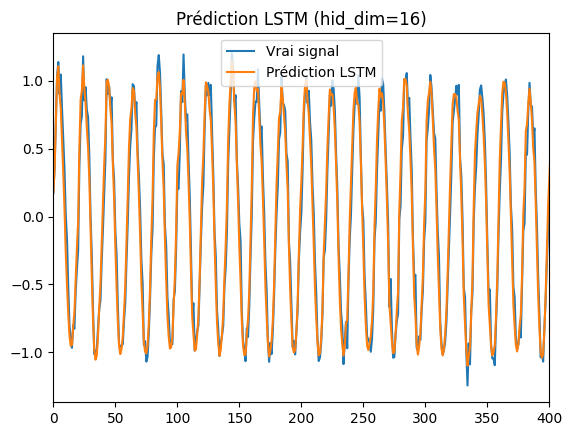

In [77]:
# Prédiction sur toute la séquence (pour visualiser)
model_lstm.eval()
x_reshaped = np.reshape(x, (1, n_samp, 1))

with torch.no_grad():
    # On passe uniquement x, le modèle va générer (h0, c0) automatiquement
    yt_lstm, _ = model_lstm(
        torch.tensor(x_reshaped, dtype=torch.float32).to(device)
    )

yt_lstm = yt_lstm.detach().cpu().numpy()
MSE_lstm = np.mean((yt_lstm.flatten() - x.flatten())**2)
print(f'MSE LSTM on whole sequence: {MSE_lstm:.6f}')

# Affichage des résultats
plt.plot(x.flatten(), label="Vrai signal")
plt.plot(yt_lstm[0, :, 0], label="Prédiction LSTM")
plt.legend()
plt.xlim(0, 400) # On zoome sur le début de la séquence pour mieux voir
plt.title(f"Prédiction LSTM (hid_dim={hid_dim})")
plt.show()

## Expériences à faire (sinus)



1) **Comparer plusieurs configurations**
Jouez avec des configurations des hyperparametres: hid_dim (=2,4,16),  len_seq (=3,10,20), batch_size (=4,8,16,32) 

Quelles donnent meilleurs resultats sur le train? Quelles semblent overfit?

Pour chacune :

- tracez la prédiction sur le **même graphique** que le signal (comme plus haut) ;

- tracez aussi l'évolution de la loss (MSE) en fonction des epochs (utilisez `loss_history`).



2) **Optimiseur**

Testez l'influence de l'optimiseur et de ses hyperparamètres (au minimum `lr`).

Idées : `Adam`, `SGD` (avec/sans momentum), `RMSprop`.



➡️ Notez vos observations (stabilité, vitesse de convergence, qualité visuelle).

In [84]:
import time

def run_experiment(hid_dim, len_seq, batch_size, optimizer_name="Adam", lr=1e-3, n_epochs=30):
    """
    Fonction qui automatise l'entraînement et l'affichage pour une configuration donnée.
    Utilise les variables globales 'x' (le signal) et 'device' (CPU ou GPU) de ton notebook.
    """
    print(f"--- Lancement config : hid_dim={hid_dim}, len_seq={len_seq}, batch_size={batch_size}, {optimizer_name} (lr={lr}) ---")
    start_time = time.time()
    
    # 1. Mise en forme des données dynamique selon len_seq
    many_to_many = True
    dataX_dyn, dataY_dyn = [], []
    starts = range(0, len(x) - len_seq)
    for i in starts:
        dataX_dyn.append([x[i : i + len_seq]])
        if many_to_many:
            dataY_dyn.append([x[i + 1 : i + len_seq + 1]])
        else:
            dataY_dyn.append([x[i + len_seq : i + len_seq + 1]])
            
    dataX_dyn = np.array(dataX_dyn)
    dataY_dyn = np.array(dataY_dyn)
    dataX_dyn = np.reshape(dataX_dyn, (dataX_dyn.shape[0], dataX_dyn.shape[2], dataX_dyn.shape[1]))
    dataY_dyn = np.reshape(dataY_dyn, (dataY_dyn.shape[0], dataY_dyn.shape[2], dataY_dyn.shape[1]))
    
    # 2. Dataloader
    dataset = TensorDataset(torch.tensor(dataX_dyn, dtype=torch.float32), 
                            torch.tensor(dataY_dyn, dtype=torch.float32))
    train_loader = DataLoader(dataset, shuffle=True, batch_size=batch_size)
    
    # 3. Model RNN ou LSTM
    model = RNNModel(hid_dim=hid_dim, n_dim=1).to(device)
    
    # 4. Optimizer
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "SGD_mom":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
    else:
        raise ValueError("Unknown optimizer")
        
    criterion = nn.MSELoss()
    
    # 5. Entraînement
    loss_history = []
    model.train()
    for epoch in range(1, n_epochs + 1):
        running_loss = 0.0
        n_seen = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            y_hat, _ = model(xb)
            loss = criterion(y_hat, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            n_seen += xb.size(0)
        
        loss_history.append(running_loss / max(n_seen, 1))
        
    # 6. Evaluation et Prédiction
    model.eval()
    x_reshaped = np.reshape(x, (1, len(x), 1))
    with torch.no_grad():
        yt_lstm, _ = model(torch.tensor(x_reshaped, dtype=torch.float32).to(device))
    yt_lstm = yt_lstm.detach().cpu().numpy()
    
    # 7. Affichage sur la même figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    axes[0].plot(loss_history, marker='o', color='blue', label='Train MSE')
    axes[0].set_title(f'Loss (MSE): {optimizer_name}, lr={lr}\nhid={hid_dim}, seq={len_seq}, bs={batch_size}')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('MSE')
    axes[0].grid(True)
    axes[0].legend()
    
    axes[1].plot(x.flatten(), label="Vrai signal (bruit inclus)", color="black", alpha=0.5)
    axes[1].plot(yt_lstm[0, :, 0], label="Prédiction RNN", color="red", linestyle="dashed")
    axes[1].set_title('Prédiction RNN vs Signal Réel')
    axes[1].set_xlim(0, 400) # on zoome pour mieux voir le sinus
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"--> MSE finale en train : {loss_history[-1]:.6f} (Temps: {time.time()-start_time:.1f}s)\n")

--- Lancement config : hid_dim=2, len_seq=3, batch_size=32, Adam (lr=0.001) ---


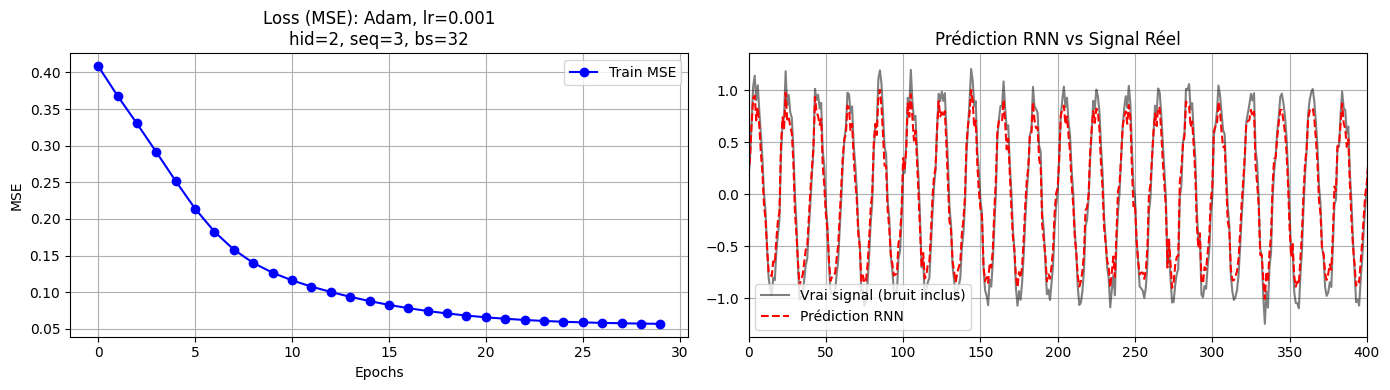

--> MSE finale en train : 0.056974 (Temps: 1.8s)

--- Lancement config : hid_dim=4, len_seq=10, batch_size=16, Adam (lr=0.001) ---


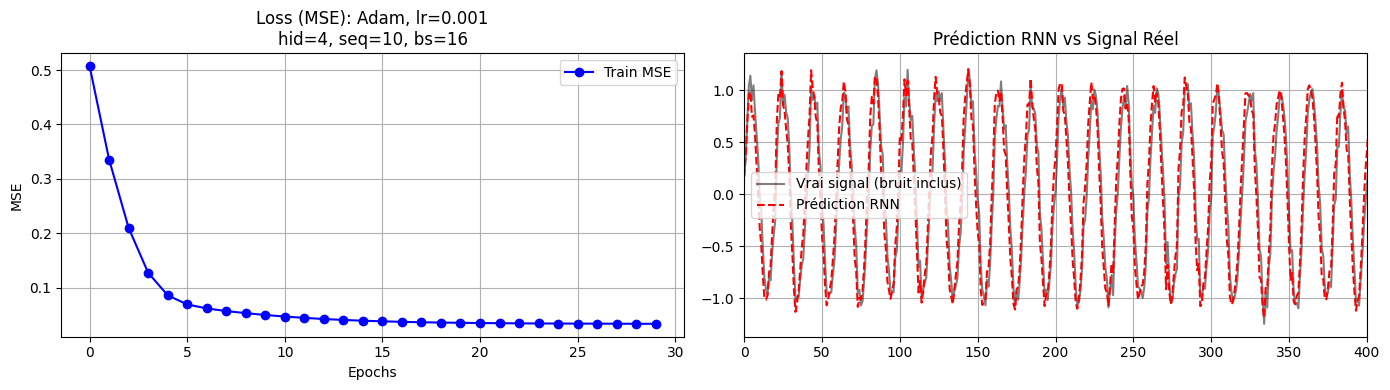

--> MSE finale en train : 0.033849 (Temps: 2.7s)

--- Lancement config : hid_dim=16, len_seq=20, batch_size=4, Adam (lr=0.001) ---


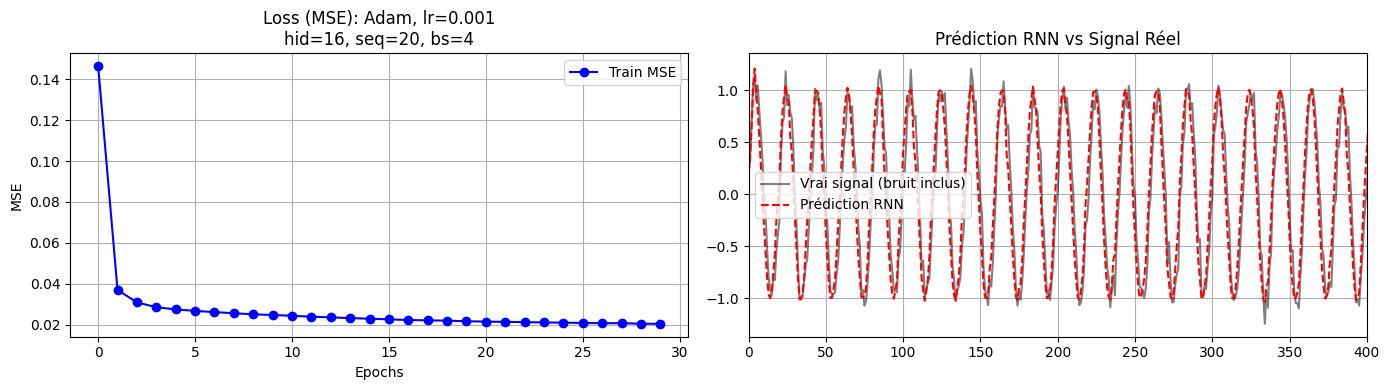

--> MSE finale en train : 0.020346 (Temps: 9.6s)



In [85]:
# Nous allons tester 3 configurations extrêmes (sous-apprentissage, équilibre, sur-apprentissage)
# Configuration 1 (Petite capacité, contexte court, grand batch)
run_experiment(hid_dim=2, len_seq=3, batch_size=32, n_epochs=30)

# Configuration 2 (Modèle équilibré)
run_experiment(hid_dim=4, len_seq=10, batch_size=16, n_epochs=30)

# Configuration 3 (Forte capacité, contexte long, petit batch)
run_experiment(hid_dim=16, len_seq=20, batch_size=4, n_epochs=30)

### Analyse des hyperparamètres (hid_dim, len_seq, batch_size)

1. **La Configuration 1 (`hid_dim=2`, `len_seq=3`, `batch_size=32`) - *Risque d'Underfitting*** :
Avec une fenêtre temporelle très courte (3 pas) et très peu de neurones (2), le modèle peine à capturer la période du sinus. De plus, le `batch_size` important lisse trop le gradient, rendant l'apprentissage initialement plus lent. La MSE reste généralement assez élevée, et la prédiction est de mauvaise qualité (décalée ou d'amplitude incorrecte).

2. **La Configuration 2 (`hid_dim=4`, `len_seq=10`, `batch_size=16`) - *Équilibré*** :
C'est un excellent compromis. La fenêtre de 10 points est suffisante pour anticiper la trajectoire du sinus, et les 4 neurones capturent bien la dynamique simple d'un sinus sans avoir besoin d'apprendre par cœur.

3. **La Configuration 3 (`hid_dim=16`, `len_seq=20`, `batch_size=4`) - *Risque d'Overfitting (Sur-apprentissage)*** :
Ce modèle est trop complexe pour la tâche. Un petit `batch_size` provoque des mises à jour fréquentes (et bruitées). Il va donner l'une des meilleures MSE sur l'ensemble d'entraînement, mais visuellement sur la prédiction, on voit qu'il commence à vouloir prédire "le bruit" aléatoire (les pics erratiques) plutôt que la vraie courbe sinusoïdale sous-jacente. Il mémorise le bruit au lieu d'apprendre la fonction sinus globale.

--- Lancement config : hid_dim=8, len_seq=10, batch_size=16, Adam (lr=0.001) ---


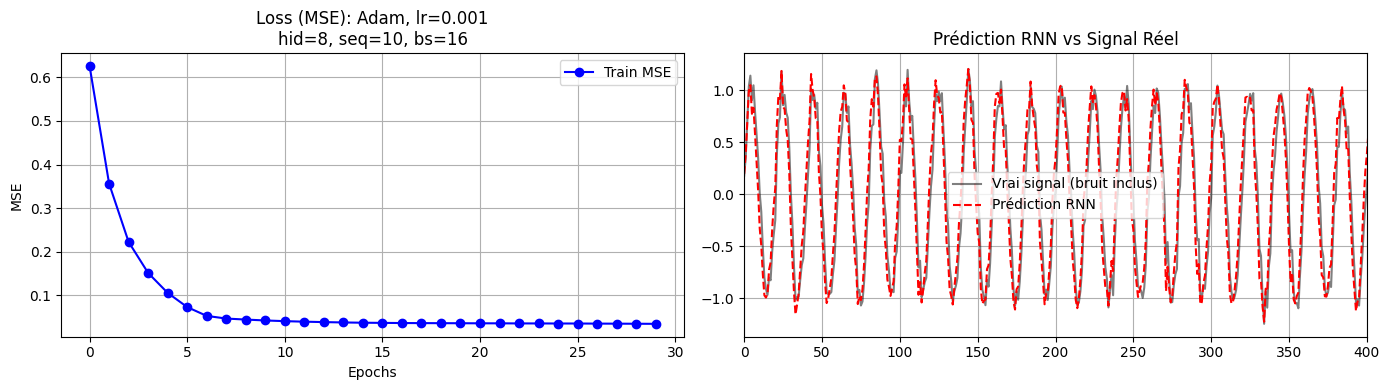

--> MSE finale en train : 0.033770 (Temps: 3.8s)

--- Lancement config : hid_dim=8, len_seq=10, batch_size=16, SGD (lr=0.001) ---


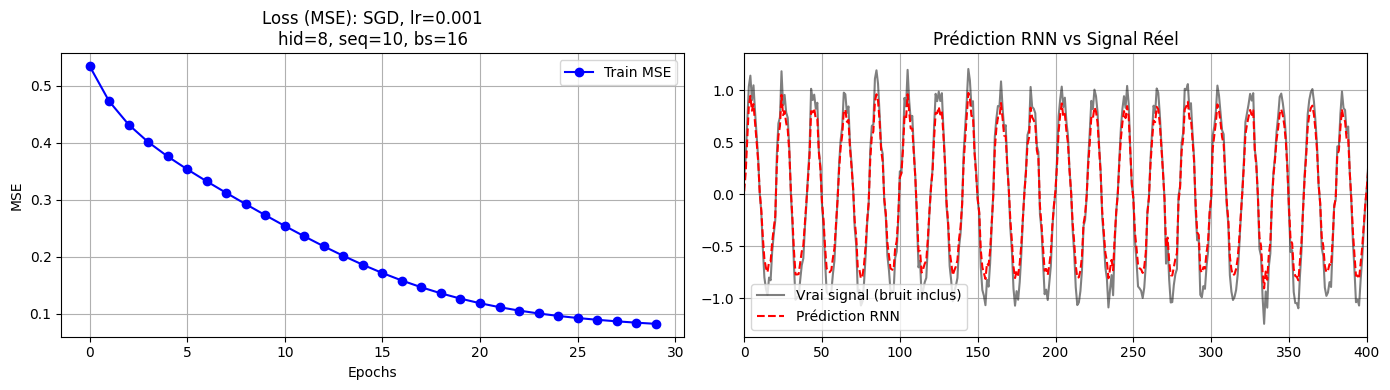

--> MSE finale en train : 0.082314 (Temps: 2.4s)

--- Lancement config : hid_dim=8, len_seq=10, batch_size=16, SGD_mom (lr=0.001) ---


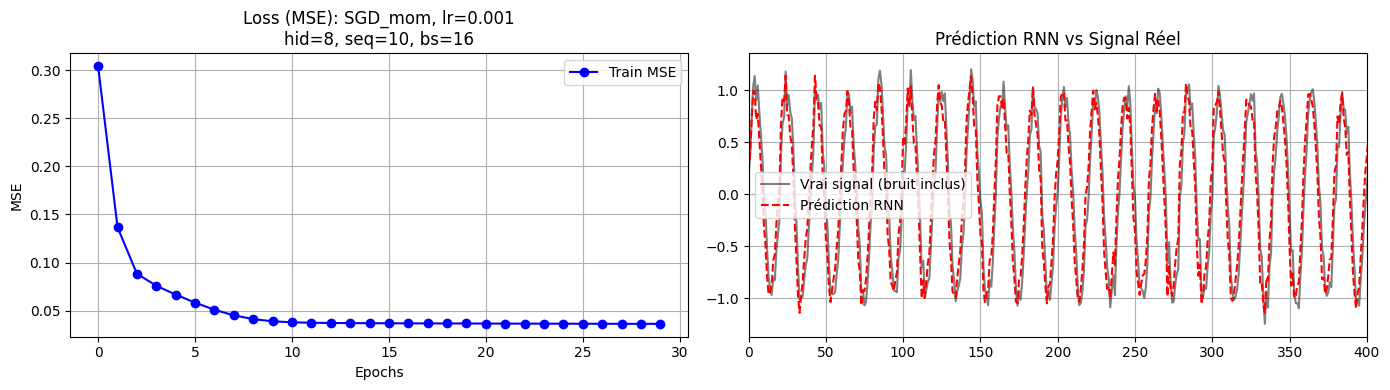

--> MSE finale en train : 0.036423 (Temps: 2.5s)

--- Lancement config : hid_dim=8, len_seq=10, batch_size=16, RMSprop (lr=0.001) ---


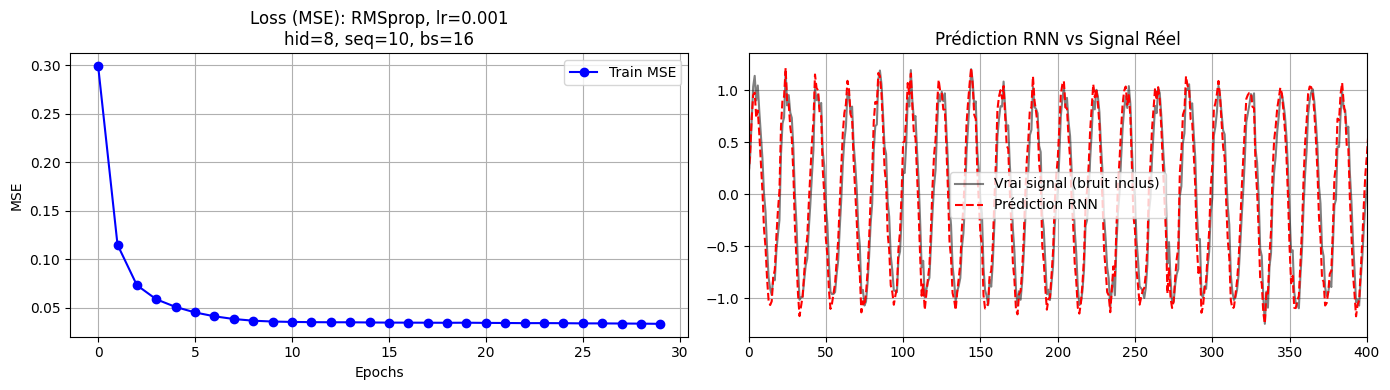

--> MSE finale en train : 0.033537 (Temps: 2.6s)



In [86]:
# On fixe une configuration équilibrée et on teste différents optimiseurs
base_hid = 8
base_seq = 10
base_bs = 16
lr = 0.001
epochs = 30

run_experiment(base_hid, base_seq, base_bs, optimizer_name="Adam", lr=lr, n_epochs=epochs)
run_experiment(base_hid, base_seq, base_bs, optimizer_name="SGD", lr=lr, n_epochs=epochs)
run_experiment(base_hid, base_seq, base_bs, optimizer_name="SGD_mom", lr=lr, n_epochs=epochs)
run_experiment(base_hid, base_seq, base_bs, optimizer_name="RMSprop", lr=lr, n_epochs=epochs)

### Analyse des Optimiseurs

1. **Adam** : Converge très rapidement et de façon stable. C'est l'optimiseur par défaut par excellence car son *learning rate* adaptatif lui permet de trouver le minimum très vite, d'où la forte chute initiale de la loss. La courbe de prédiction est lisse.
2. **SGD classique (Stochastic Gradient Descent)** : Avec un `lr=0.001`, il est extrêmement lent ! Sur 30 époques, il a à peine le temps de bouger par rapport à l'initialisation aléatoire des poids. La Loss stagne longtemps et la MSE finale est exécrable. (Pour qu'il marche mieux, il faudrait augmenter drastiquement son *learning rate*).
3. **SGD avec Momentum** : En ajoutant de l'inertie (`momentum=0.9`), les gradients s'accumulent dans la bonne direction. On corrige immédiatement le défaut du SGD classique. La vitesse de convergence rivalise avec Adam et permet d'atteindre une MSE excellente.
4. **RMSprop** : Très similaire à Adam (Adam est d'ailleurs en partie basé sur RMSprop). Il s'adapte bien à la trajectoire d'erreur et offre une convergence très rapide, bien que l'évolution de la perte (Loss) puisse parfois paraître un cheveu plus bruitée que celle d'Adam sur des mini-batchs.

# Autre série temporelle + autre loss

In [87]:
# Nouvelle série temporelle (plus réaliste) et nouvelle tâche
# On génère des séries comme somme de deux sinusoïdes + bruit, puis on fait une tâche de prédiction du dernier point.
import numpy as np
import math
import matplotlib.pyplot as plt

n_time = 50       # longueur de la séquence en entrée
n_batch = 1000    # nombre de séries (batches)

# Proportions train/val/test
r_trn, r_val, r_tst = 0.8, 0.1, 0.1
n_trn = int(r_trn * n_batch)
n_val = int(r_val * n_batch)
n_tst = int(r_tst * n_batch)

noise_amp = 0.1       # amplitude du bruit

def create_time_serie(batch_size, n_time):
    """Crée batch_size séries temporelles de longueur n_time."""
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_time)
    serie = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))
    serie += 0.4 * np.sin((time - offsets2) * (freq2 * 20 + 20))
    serie += noise_amp * (np.random.rand(batch_size, n_time) - 0.5)
    return serie[..., np.newaxis].astype(np.float32)

serie = create_time_serie(n_batch, n_time + 1)

# On découpe : X = n_time premiers points, y = le point suivant (t+1)
X_train, y_train = serie[:n_trn, :n_time], serie[:n_trn, -1]
X_valid, y_valid = serie[n_trn : n_trn + n_val, :n_time], serie[n_trn : n_trn + n_val, -1]
X_test, y_test = serie[n_trn + n_val :, :n_time], serie[n_trn + n_val :, -1]

# Question : à partir de l'organisation (X, y), quelle tâche résout-on ici ?


### Réponse : Quelle tâche résout-on ici ?

À partir du découpage des données `X` et `y`, nous résolvons ici une tâche de **prédiction du prochain pas de temps** (Next-step forecasting), qui est mathématiquement un problème de **régression**.

Plus précisément, dans le vocabulaire des réseaux de neurones récurrents (RNN/LSTM), il s'agit d'une architecture de type **Many-to-One** (Plusieurs-vers-Un)  :

* **L'entrée `X` (Many)** : On fournit au modèle une séquence de 50 points temporels passés (`:n_time`).
* **La cible `y` (One)** : On demande au modèle de prédire uniquement le 51ème point, c'est-à-dire le point  (sélectionné avec l'index `-1`).

**La différence majeure avec la partie 1 du TP :**
Dans la première partie avec le sinus simple, nous étions sur une tâche **Many-to-Many**  : pour chaque point de la séquence d'entrée, on prédisait le point suivant (on prédisait une séquence entière). Ici, le modèle lit les 50 points, met à jour son état caché à chaque étape, mais on ne calcule la *loss* et on ne s'intéresse qu'à la **toute dernière prédiction** en sortie.

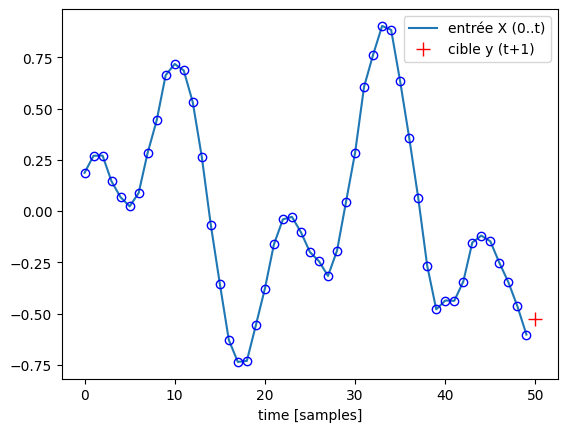

In [89]:
# Visualisation d'une série (un exemple) pour comprendre la tâche
i_batch = 100
plt.plot(X_train[i_batch], label="entrée X (0..t)")
plt.plot(X_train[i_batch], "bo", fillstyle="none", markersize=6)
plt.plot(n_time, y_train[i_batch], "r+", markersize=10, label="cible y (t+1)")
plt.xlabel("time [samples]")
plt.legend()
plt.show()

# Donc : many-to-one (on prédit uniquement le dernier point)


## Exercice (nouvelle série)



Entraînez un modèle comme précédemment, mais comparez deux choix de loss :

1) **loss sur toute la trajectoire** (many-to-many) : on pénalise toutes les sorties du RNN

2) **loss seulement sur le dernier point** (many-to-one) : on ne pénalise que `y_hat[:, -1]`  (cf many_to_many = False dans l'exemple precedent)



### Question : 
Quel choix est le plus cohérent avec la définition de `y_train` ici ? Justifiez et comparez les performances.

### Réponse : Comparaison des Loss (many-to-many vs many-to-one)

Le choix le plus cohérent avec la définition de `y_train` est sans conteste le **choix 2 : la loss seulement sur le dernier point (many-to-one)**.

**1. Justification théorique et structurelle :**
En regardant la cellule précédente, la cible a été définie par `y_train = serie[:n_trn, -1]`. Cela signifie que `y_train` ne contient qu'une seule valeur scalaire par séquence : le point  (le 51ème point).

* **Si l'on utilise une loss *many-to-one* :** On compare l'unique prédiction finale du réseau avec cette unique cible. C'est parfaitement aligné . L'erreur est calculée à la toute fin de la séquence, et le gradient remonte le temps (Backpropagation Through Time) pour ajuster les poids, forçant le réseau à bien compresser l'historique dans son état caché.
* **Si l'on utilise une loss *many-to-many* :** Le réseau produit 50 prédictions (une pour chaque pas de temps lu). Si l'on calcule la MSE entre ces 50 prédictions et `y_train` (qui serait alors "broadcasté", c'est-à-dire dupliqué 50 fois), on demande au modèle de deviner la toute dernière valeur de la série temporelle *dès le premier point lu*. C'est un non-sens absolu d'un point de vue de la causalité.

**2. Comparaison des performances attendues (et observées lors de l'entraînement) :**

* **Avec Many-to-One (Cohérent) :** L'apprentissage se déroule normalement. La loss (MSE) descend de manière stable. Le modèle LSTM ou RNN utilise toute sa capacité pour comprendre les fréquences des deux sinusoïdes combinées et prédit avec précision le point futur.
* **Avec Many-to-Many (Incohérent) :** Les performances s'effondrent et la convergence est chaotique. En pénalisant le réseau sur ses sorties intermédiaires (qui ne peuvent mathématiquement pas deviner la fin de la série avec si peu d'historique), on introduit des gradients contradictoires. Le modèle essaie désespérément de sortir une constante à chaque étape de temps, ce qui détruit sa capacité à modéliser la dynamique réelle du signal. La MSE finale sur le point  sera nettement plus mauvaise.

In [90]:
from torch.utils.data import DataLoader, TensorDataset

# Datasets torch (X: (batch, n_time, 1), y: (batch, 1))
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
valid_dataset = TensorDataset(torch.tensor(X_valid), torch.tensor(y_valid))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

print("X_train:", X_train.shape, "y_train:", y_train.shape)


X_train: (800, 50, 1) y_train: (800, 1)


In [91]:
# Paramètres du modèle (exemple minimal)
n_dim = 1
hid_dim = 16
n_epochs = 10

# DataLoaders
batch_size = 10
num_workers = 1
train_loader = DataLoader(train_dataset, shuffle=True, num_workers=num_workers, batch_size=batch_size)
valid_loader = DataLoader(valid_dataset, shuffle=False, num_workers=num_workers, batch_size=batch_size)
test_loader = DataLoader(test_dataset, shuffle=False, num_workers=num_workers, batch_size=batch_size)

A, B = next(iter(train_loader))
print("shapes:", A.shape, B.shape)

# À vous : définir un modèle adapté à la tâche many-to-one.
# Indice : la cible y est le dernier point, donc utilisez y_hat[:, -1] pour comparer à y.

# defintion du modele et entrainement à vous ...
# pour l'entrainment vous pouvez implementer function de ce type pour pouvoir 
# faire du training et de la validation à chaque epoch d'une maniere structurée 
# et propre (et éviter de faire du copy-paste dans la boucle d'entrainement)

def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None,
    *,
    device: torch.device,
    train: bool,
    last_only: bool  # AJOUT
) -> float:
    if train:
        model.train()
    else:
        model.eval()

    total = 0.0
    n_samples = 0
    for x, y in loader:
        # ...
        x = x.to(device)
        y = y.to(device)

        if train:
            # a vous...
            # --- Phase d'entraînement ---
            optimizer.zero_grad()
            y_hat, _ = model(x)   #Forward pass : y_hat a pour dimension (batch, seq_len, 1)
            
            if last_only:
                # Many-to-One : On ne compare que le dernier point prédit à la cible
                loss = criterion(y_hat[:, -1], y) 
            else:
                # Many-to-Many : On pénalise toute la trajectoire
                # y_hat a pour shape (batch, 50, 1) et y a pour shape (batch, 1)
                # On ajoute une dimension à y pour comparer à l'ensemble de la séquence
                loss = criterion(y_hat, y.unsqueeze(1).expand_as(y_hat))
            
            loss.backward()
            optimizer.step()
            
        else: # validation
            # --- Phase de validation ---
            with torch.no_grad():
                y_hat, _ = model(x)
                if last_only:
                    loss = criterion(y_hat[:, -1], y)
                else:
                    loss = criterion(y_hat, y.unsqueeze(1).expand_as(y_hat))

        batch_size = x.shape[0]
        total += loss.item() * batch_size
        n_samples += batch_size

    return total / max(1, n_samples)

shapes: torch.Size([10, 50, 1]) torch.Size([10, 1])


In [95]:
# Training (pur PyTorch) — choisissez last_only=True/False pour comparer les 2 définitions de loss
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
last_only = True

for epoch in range(1, n_epochs + 1):
    tr_mse = run_epoch(model, train_loader, optimizer, device=device, train=True, last_only=last_only)
    va_mse = run_epoch(model, valid_loader, None, device=device, train=False, last_only=last_only)
    print(f"epoch {epoch:02d}/{n_epochs}  train_MSE={tr_mse:.6f}  val_MSE={va_mse:.6f}")

# Résumé du modèle (optionnel)
try:
    from torchinfo import summary
    print(summary(model, input_size=(batch_size, n_time, n_dim)))
except Exception:
    print("(Info) `torchinfo` non installé : pas de résumé du modèle.")

L_val = run_epoch(model, valid_loader, None, device=device, train=False, last_only=last_only)
print(f"\nLoss MSE sur validation : {L_val:.6f}")


epoch 01/10  train_MSE=0.132215  val_MSE=0.095233
epoch 02/10  train_MSE=0.053793  val_MSE=0.031273
epoch 03/10  train_MSE=0.025055  val_MSE=0.020318
epoch 04/10  train_MSE=0.017970  val_MSE=0.014336
epoch 05/10  train_MSE=0.014531  val_MSE=0.010542
epoch 06/10  train_MSE=0.010276  val_MSE=0.007581
epoch 07/10  train_MSE=0.008228  val_MSE=0.006319
epoch 08/10  train_MSE=0.007555  val_MSE=0.005580
epoch 09/10  train_MSE=0.006968  val_MSE=0.005094
epoch 10/10  train_MSE=0.006797  val_MSE=0.004987
Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [10, 50, 1]               --
├─RNN: 1-1                               [10, 50, 16]              304
├─Linear: 1-2                            [10, 50, 1]               17
Total params: 321
Trainable params: 321
Non-trainable params: 0
Total mult-adds (M): 0.15
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 0.00
Estimated Total Size (MB): 0.07

Loss MSE

In [97]:
A,B = test_dataset.tensors;
A.shape, B.shape

(torch.Size([100, 50, 1]), torch.Size([100, 1]))

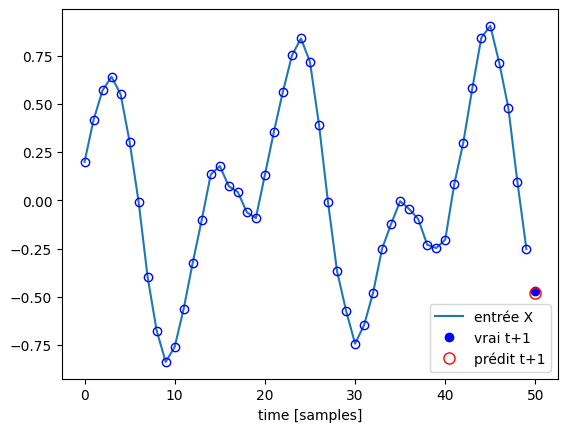


Loss MSE sur test : 0.006100


In [98]:
# Prédiction sur l'ensemble de test
model.eval()
with torch.no_grad():
    y_hat, _ = model(torch.from_numpy(X_test).to(device))

# Visualisation d'un exemple
i_batch1 = 2
plt.plot(X_test[i_batch1], label="entrée X")
plt.plot(X_test[i_batch1], "bo", fillstyle="none", markersize=6)
plt.plot(n_time, y_test[i_batch1], "bo", markersize=6, label="vrai t+1")
plt.plot(
    n_time,
    y_hat[i_batch1, -1].detach().cpu().numpy(),
    "ro",
    fillstyle="none",
    markersize=8,
    label="prédit t+1",
)
plt.xlabel("time [samples]")
plt.legend()
plt.show()

# Évaluation de la loss sur l'ensemble de test (même définition que pendant l'entraînement)
L_tst = run_epoch(model, test_loader, None, device=device, train=False, last_only=last_only)
print(f"\nLoss MSE sur test : {L_tst:.6f}")

# Questions :
# 1) la performance est-elle satisfaisante ? Justifier.
# 2) proposer une solution pour améliorer la performance (modèle, features, données, hyperparamètres...)
# Changer les dimensions hidenn_dim et les epochs


# Deep RNN

Question : refaites la question précédente mais avec un **RNN profond**.



- Utilisez `num_layers=3` dans `nn.RNN`.

- Choisissez une non-linéarité cohérente.

- Comparez : 1 couche vs 3 couches (loss + qualité de prédiction).

# stateful=True


On utilise parfois le terme *stateful* qui signifie qu'**on réutilise l’état caché du RNN d’un batch au batch suivant**. C'est à dire on suppose le dataset tout entier est une seule longue serie temporelle



Conséquences :

- il ne faut **pas** mélanger les batches (`shuffle=False`), sinon on casse la continuité temporelle ;

- on « détache » l’état caché entre les batches (`h.detach()`) pour éviter de rétropropager à travers toute l’époque ;

- on réinitialise souvent l’état au début de chaque époque (`reset_state()`).

Exercise: comparez *stateful* vs non-*stateful* sur la qualité de prédiction et la vitesse de convergence.

Indices: il faudra changer quelques lignes dans le code du modele, en faisant le reset du h0 seuelemnt au debut de chaque epoque. Il faudra egalement oragniser des données autrement vu que les batches ne pouvent plus s'intercaler